 **MILESTONE 1**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv(r"/content/us_perm_visas.csv")
print(df)

                             add_these_pw_job_title_9089  agent_city  \
0                                                    NaN         NaN   
1                                                    NaN         NaN   
2                                                    NaN         NaN   
3                                                    NaN         NaN   
4                                                    NaN         NaN   
...                                                  ...         ...   
25939                          Computer Systems Analysts         NaN   
25940                               ELECTRICAL ENGINEERS         NaN   
25941                  Software Developers, Applications         NaN   
25942                           Computer Systems Analyts         NaN   
25943  Market Research Analysts and Marketing Special...         NaN   

       agent_firm_name  agent_state application_type        case_no  \
0                  NaN          NaN             PERM  A-07323-97

/tmp/ipykernel_695/1485715980.py:1: DtypeWarning: Columns (0,10,11,22,79,80,86,150) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"/content/us_perm_visas.csv")


In [ ]:
print("Original Shape:", df.shape)

Original Shape: (25944, 154)


In [ ]:
# Check missing values
print("\nMissing values:\n", df.isnull().sum())



Missing values:
 add_these_pw_job_title_9089      20646
agent_city                       25944
agent_firm_name                  25944
agent_state                      25944
application_type                     0
                                 ...  
wage_offer_to_9089               21295
wage_offer_unit_of_pay_9089       5370
wage_offered_from_9089           20577
wage_offered_to_9089             24590
wage_offered_unit_of_pay_9089    25944
Length: 154, dtype: int64


In [ ]:
# Handle missing values
df["country_of_citzenship"] = df["country_of_citzenship"].fillna("Unknown")

df.rename(columns={
    "country_of_citzenship": "country"
}, inplace=True)


In [ ]:
# Convert decision date
df["decision_date"] = pd.to_datetime(df["decision_date"], errors="coerce")
df = df.dropna(subset=["decision_date"])



In [ ]:
# Generate application date
np.random.seed(42)

processing_days = np.random.randint(30, 180, len(df))

df["processing_days"] = processing_days
df["application_date"] = df["decision_date"] - pd.to_timedelta(processing_days, unit="D")



In [ ]:
# Calculate processing days
df["processing_days"] = (df["decision_date"] - df["application_date"]).dt.days



In [ ]:
# Rename columns (simple names)
df.rename(columns={
    "country_of_citizenship": "country",
    "class_of_admission": "visa_type",
    "employer_state": "processing_office"
}, inplace=True)

In [ ]:
# Encoding categorical
df_encoded = pd.get_dummies(
    df[["processing_days","country","visa_type","processing_office"]],
    drop_first=True
)


In [ ]:
# Save cleaned dataset
# -------------------------
df_encoded.to_csv("visa_milestone1_cleaned.csv", index=False)

print("\nFinal dataset shape:", df_encoded.shape)
print(df_encoded.head())


Final dataset shape: (25943, 404)
   processing_days  country_ALBANIA  country_ARGENTINA  country_ARMENIA  \
0              132            False              False            False   
1              122            False              False            False   
2               44            False              False            False   
3              136            False              False            False   
4              101            False              False            False   

   country_AUSTRALIA  country_AUSTRIA  country_AZERBAIJAN  country_BAHAMAS  \
0              False            False               False            False   
1              False            False               False            False   
2              False            False               False            False   
3              False            False               False            False   
4              False            False               False            False   

   country_BANGLADESH  country_BELARUS  ...  

**MILESTONE 2**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

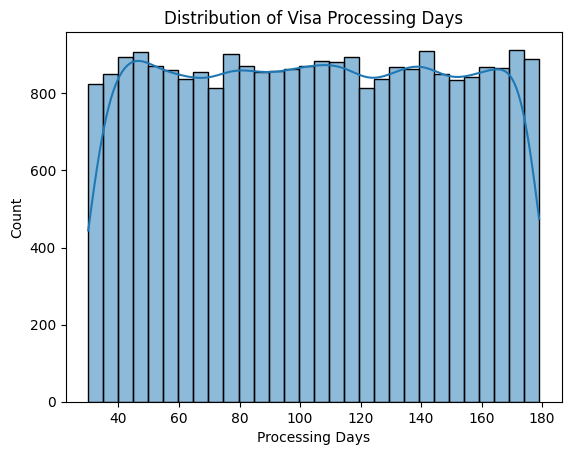

In [ ]:
# Distribution of Processing Days
sns.histplot(df["processing_days"], kde=True)
plt.title("Distribution of Visa Processing Days")
plt.xlabel("Processing Days")
plt.ylabel("Count")
plt.show()

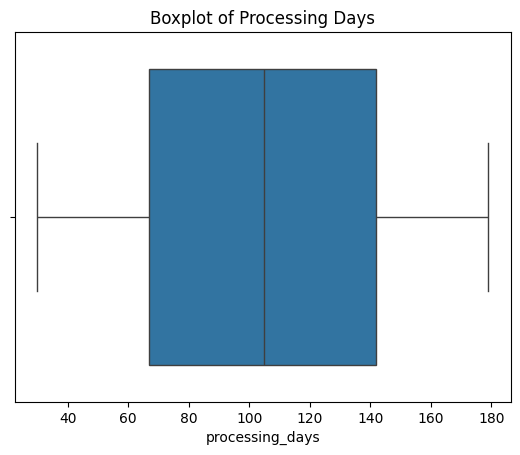

In [ ]:
#Boxplot (Outlier Detection)
sns.boxplot(x=df["processing_days"])
plt.title("Boxplot of Processing Days")
plt.show()

In [ ]:
df = df.loc[:, ~df.columns.duplicated()]

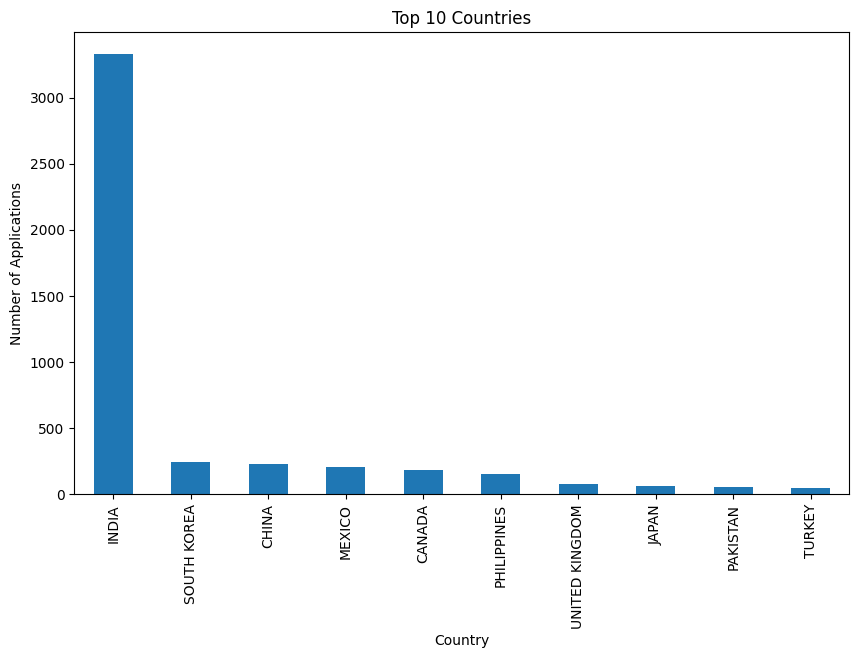

In [ ]:
# Top 10 Countries by Applications

plt.figure(figsize=(10,6))

df["country"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Applications")

plt.show()

In [ ]:
# Feature: Application Month
df["application_month"] = df["application_date"].dt.month

In [ ]:
# Correlation Matrix
corr_matrix = df[["processing_days", "application_month"]].corr()
print("\nCorrelation Matrix:\n", corr_matrix)



Correlation Matrix:
                    processing_days  application_month
processing_days           1.000000          -0.106048
application_month        -0.106048           1.000000


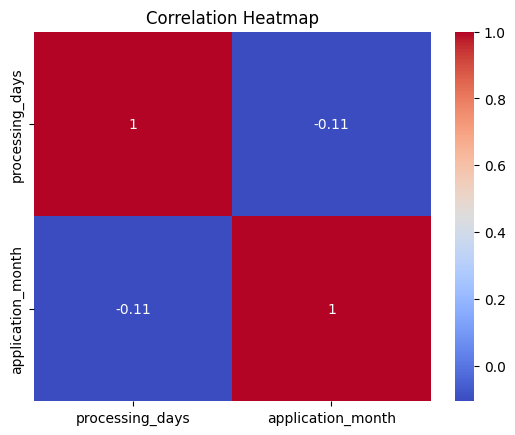

In [ ]:
# correlation heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

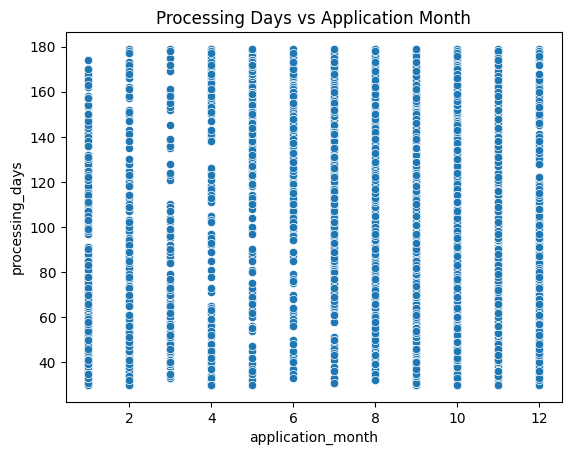

In [ ]:
# Scatter Plot
sns.scatterplot(
    x="application_month",
    y="processing_days",
    data=df
)
plt.title("Processing Days vs Application Month")
plt.show()

In [ ]:
#Feature:Application Month
print(df[["application_date", "application_month"]].head())

#Feature:Seasonal Index (Peak vs Off-Peak)
df["season"] = df["application_month"].apply(
    lambda x: "Peak" if x in [1, 2, 12] else "Off-Peak"
)
print(df[["application_month", "season"]].head())

#Feature:Country Specific Average Processing Time
country_avg = df.groupby("country")["processing_days"].mean()
df["country_avg"] = df["country"].map(country_avg)
print("\nCountry-wise Average Processing Time:\n", country_avg.head())

#Feature:Visa Type Average Processing Time
visa_avg = df.groupby("visa_type")["processing_days"].mean()
df["visa_avg"] = df["visa_type"].map(visa_avg)
print("\nVisa-Type Average Processing Time:\n", visa_avg.head())
df.to_csv("visa_milestone2_feature_engineered.csv", index=False)
print(df.head())

  application_date  application_month
0       2011-09-22                  9
1       2011-08-21                  8
2       2011-10-18                 10
3       2011-07-18                  7
4       2011-10-17                 10
   application_month    season
0                  9  Off-Peak
1                  8  Off-Peak
2                 10  Off-Peak
3                  7  Off-Peak
4                 10  Off-Peak

Country-wise Average Processing Time:
 country
AFGHANISTAN    116.500000
ALBANIA        123.666667
ARGENTINA      113.166667
ARMENIA         40.000000
AUSTRALIA      104.954545
Name: processing_days, dtype: float64

Visa-Type Average Processing Time:
 visa_type
A-3         120.666667
A1/A2       102.866667
AOS/H-1B     59.000000
B-1         100.662338
B-2         103.007979
Name: processing_days, dtype: float64
  add_these_pw_job_title_9089  agent_city  agent_firm_name  agent_state  \
0                         NaN         NaN              NaN          NaN   
1                   

In [ ]:
print(df["country"].value_counts().head(10))

country
INDIA             3329
SOUTH KOREA        242
CHINA              224
MEXICO             203
CANADA             181
PHILIPPINES        149
UNITED KINGDOM      75
JAPAN               61
PAKISTAN            53
TURKEY              49
Name: count, dtype: int64


In [ ]:
print(df.columns)

Index(['add_these_pw_job_title_9089', 'agent_city', 'agent_firm_name',
       'agent_state', 'application_type', 'case_no', 'case_number',
       'case_received_date', 'case_status', 'visa_type',
       ...
       'wage_offer_unit_of_pay_9089', 'wage_offered_from_9089',
       'wage_offered_to_9089', 'wage_offered_unit_of_pay_9089',
       'processing_days', 'application_date', 'application_month', 'season',
       'country_avg', 'visa_avg'],
      dtype='object', length=159)


In [ ]:
for col in df.columns:
    if "country" in col.lower():
        print(col)

country
employer_country
foreign_worker_info_birth_country
fw_info_birth_country
country_avg


**MILESTONE 3 : PREDICTIVE MODELING**

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
#load dataset
df = pd.read_csv("visa_milestone2_feature_engineered.csv", low_memory=False)

print("Dataset Shape:", df.shape)

Dataset Shape: (25943, 159)


In [ ]:
# # Handle Missing Values
df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna("Unknown", inplace=True)

/tmp/ipykernel_695/1794909138.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna("Unknown", inplace=True)


In [ ]:
# Encode Categorical Variables
le_country = LabelEncoder()
le_visa = LabelEncoder()
le_office = LabelEncoder()
le_season = LabelEncoder()

df["country"] = le_country.fit_transform(df["country"].astype(str))
df["visa_type"] = le_visa.fit_transform(df["visa_type"].astype(str))
df["processing_office"] = le_office.fit_transform(df["processing_office"].astype(str))

if "season" in df.columns:
    df["season"] = le_season.fit_transform(df["season"].astype(str))

In [ ]:
# Select Features and Target
X = df[
[
    "country",
    "visa_type",
    "processing_office",
    "application_month",
    "country_avg",
    "visa_avg"
]
]

y = df["processing_days"]

print("Feature Shape:", X.shape)

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Feature Shape: (25943, 6)
Training Samples: (20754, 6)
Testing Samples: (5189, 6)


In [ ]:
# Training different models
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),

    "Support Vector Regression": SVR()
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)

    mse = mean_squared_error(y_test, preds)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, preds)

    results.append([name, mae, rmse, r2])

In [ ]:
df = df.sample(20000, random_state=42)

In [ ]:
#model comparision
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

print("\nModel Comparison:\n")
print(results_df.sort_values(by="RMSE"))


Model Comparison:

                       Model        MAE       RMSE  R2 Score
3          Gradient Boosting  28.541818  34.881354  0.352169
1              Decision Tree  28.725663  35.455954  0.330649
2              Random Forest  28.728583  35.879374  0.314567
0          Linear Regression  37.053833  43.044404  0.013474
4  Support Vector Regression  37.349654  43.183250  0.007099


In [ ]:
#Hyperparameter tuning
print("\nRunning Hyperparameter Tuning for Random Forest...")

rf = RandomForestRegressor(random_state=42)

param_grid = {

    "n_estimators": [100, 200],

    "max_depth": [10, 20, None],

    "min_samples_split": [2, 5],

    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(

    rf,
    param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1

)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)


Running Hyperparameter Tuning for Random Forest...
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
# Evaluate Tuned Model

preds = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, preds)

rmse = np.sqrt(mean_squared_error(y_test, preds))

r2 = r2_score(y_test, preds)

print("\nTuned Random Forest Performance")

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)


Tuned Random Forest Performance
MAE: 28.326349632408554
RMSE: 34.84576424692893
R2 Score: 0.35348999721502383



Feature Importance

             Feature  Importance
3  application_month    0.843910
0            country    0.057489
2  processing_office    0.043830
4        country_avg    0.022329
5           visa_avg    0.018291
1          visa_type    0.014150


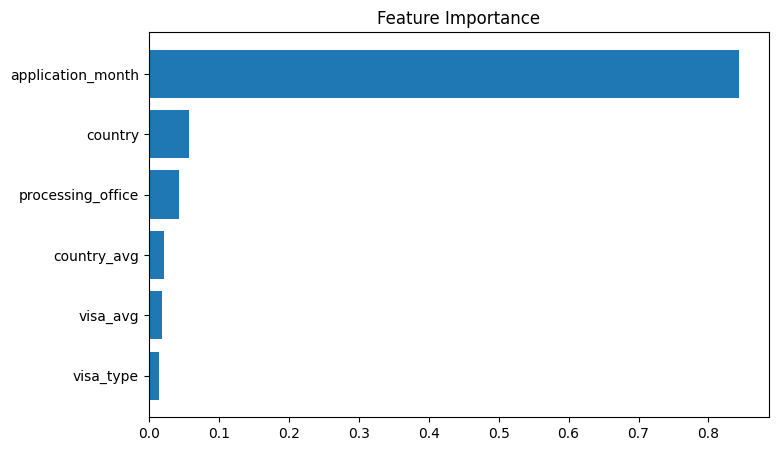

In [ ]:
# Feature Importance

import matplotlib.pyplot as plt

importances = best_rf.feature_importances_

features = X.columns

importance_df = pd.DataFrame({

    "Feature": features,

    "Importance": importances

}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance\n")

print(importance_df)

plt.figure(figsize=(8,5))

plt.barh(importance_df["Feature"], importance_df["Importance"])

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()